In [3]:
import os
import shutil
import random
from pathlib import Path


import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2

from sklearn.metrics.pairwise import cosine_distances

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

CLEAN_SOURCE = "pv_cropped_ready_integ/train/images" 
CLEAN_SOURCE2 = "pv_cropped_ready_integ/valid/images" 

# Where we will create the new organized dataset
OUTPUT_ROOT = "cell_separation_from_mixed_orig/pv_merged_crops"

# Split ratio: 70% Clean for Training, 20% Clean for Validation
TRAIN_RATIO = 0.5

CLEAN_SOURCE = "pv_cropped_ready_integ/train/images" 
CLEAN_SOURCE2 = "pv_cropped_ready_integ/valid/images" 

# Where we will create the new organized dataset
OUTPUT_ROOT = "cell_separation_from_mixed_orig/pv_merged_crops"

# Split ratio: 70% Clean for Training, 20% Clean for Validation
TRAIN_RATIO = 0.5


In [ ]:

# ==========================================
# CONFIGURATION
# ==========================================
# Path to your folder containing the raw, mixed PV images
# INPUT_FOLDER = 'cell_separation_from_mixed_orig/pv_merged_crops'
INPUT_FOLDER = r'cell_separation_from_mixed_orig\final_yolo_datasets\vendor_0\valid\images'

# Where to save the sorted images
OUTPUT_FOLDER = r'cell_separation_from_mixed_orig/final_yolo_datasets\vendor_0_sorted\valid\images'

# Expected number of vendors (If unknown, we can use elbow method, but let's start with a guess)
NUM_CLUSTERS = 12
# NUM_CLUSTERS = 4 # for vendor_0

# Image size for the model (ResNet standard is 224)
IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= CONFIGURATION =================
ROOT_DIR = 'cell_separation_from_mixed_orig/sorted_vendors'
ROOT_DIR = 'cell_separation_from_mixed_orig/cleaned_dataset_for_knn'
CACHE_FILE = 'cell_separation_from_mixed_orig/resnet_features_cache.pt'  # Where to save the "fingerprints"
CACHE_FILE = 'cell_separation_from_mixed_orig/resnet_features_cache_after_clean_grp4.pt'  # Where to save the "fingerprints"
CACHE_FILE = 'cell_separation_from_mixed_orig/resnet_features_cache_before_merge_mix_orig.pt'  # Where to save the "fingerprints"

TOP_N_OUTLIERS = 5
# =================================================

# ================= CONFIGURATION =================
# 1. Input: Where are the cleaned images?
CLEANED_IMAGES_ROOT = 'cell_separation_from_mixed_orig/cleaned_dataset_for_knn'

# 2. Input: Where should I look for labels?
SOURCE_LABEL_DIRS = [
    'pv_cropped_ready_integ/train/labels', 
    'pv_cropped_ready_integ/valid/labels', 
]

# 3. Output: Where to save the final YOLO-ready datasets?
FINAL_OUTPUT_ROOT = 'cell_separation_from_mixed_orig/final_yolo_datasets2'
# 4. Settings
VAL_PERCENT = 0.2  # 20% of data goes to Validation
IGNORE_FOLDERS = ["outliers_garbage", "other", "vendor_cluster_3 - now garbage"]
# =================================================



In [11]:

def organize_dataset(src1, dest, src2=None):
    print(f"--- Organizing Dataset ---")
    
    os.makedirs(dest, exist_ok=True)
        
    # 2. Process Clean Images (Split into Train/Test)
    clean_files = []
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')
    
    if os.path.exists(src1):
        for f in os.listdir(src1):
            if f.lower().endswith(valid_exts):
                clean_files.append(os.path.join(src1, f))
    else:
        print(f"Warning: Clean source path not found: {src1}")

    if os.path.exists(src2):
        for f in os.listdir(src2):
            if f.lower().endswith(valid_exts):
                clean_files.append(os.path.join(src2, f))
    else:
        print(f"Warning: Clean source path not found: {src2}")

    print(f"Found {len(clean_files)} clean images.")
    
    random.shuffle(clean_files)
    
    split_idx = int(len(clean_files) * TRAIN_RATIO)
    
    train_clean = clean_files[:split_idx]
    
    for f in train_clean:
        shutil.copy(f, os.path.join(dest, os.path.basename(f)))
        

    print(f"✅ Dataset organized successfully at: {dest}")



# organize_dataset(CLEAN_SOURCE, OUTPUT_ROOT, CLEAN_SOURCE2)   


In [12]:


# ==========================================
# 1. DATASET CLASS
# ==========================================
class UnlabeledPVDatasett(Dataset):
    """
    Custom dataset to load images from a flat folder without labels.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        # Get all image files (jpg, png, tif, etc.)
        self.image_files = [f for f in os.listdir(root_dir) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.bmp'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # Open image and convert to RGB (ResNet expects 3 channels, even for grayscale EL)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, img_name

# ==========================================
# 2. FEATURE EXTRACTION PIPELINE
# ==========================================
def get_feature_extractor():
    """
    Returns a ResNet50 model with the last classification layer removed.
    """
    # Load pre-trained ResNet50
    # Note: You can swap this for EfficientNet if you prefer
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    
    # Remove the final fully connected layer (fc)
    # The output will now be the 2048-dim feature vector from the pooling layer
    model = torch.nn.Sequential(*list(model.children())[:-1])
    
    model.to(DEVICE)
    model.eval() # Set to evaluation mode
    return model

def extract_features(loader, model):
    """
    Passes all images through the model and returns a numpy array of features.
    """
    features_list = []
    filenames_list = []
    
    print(f"Extracting features using {DEVICE}...")
    with torch.no_grad(): # No need to calculate gradients for extraction
        for images, filenames in tqdm(loader):
            images = images.to(DEVICE)
            
            # Forward pass
            # Output shape: (Batch_Size, 2048, 1, 1)
            outputs = model(images)
            
            # Flatten to (Batch_Size, 2048)
            outputs = outputs.view(outputs.size(0), -1)
            
            features_list.append(outputs.cpu().numpy())
            filenames_list.extend(filenames)
            
    # Concatenate all batches into one large array
    features = np.concatenate(features_list, axis=0)
    return features, filenames_list


# ==========================================
# 3. CLUSTERING PIPELINE
# ==========================================
def cluster_and_sort(features, filenames):
    print("\n--- Phase 2: Dimensionality Reduction & Clustering ---")
    
    # Step A: Dimensionality Reduction
    # 2048 dimensions is too high for K-Means to work efficiently (curse of dimensionality).
    # We use UMAP to project it down to a dense manifold.
    print("Reducing dimensions with UMAP...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine')
    embedding = reducer.fit_transform(features)
    
    # Step B: Clustering
    print(f"Clustering into {NUM_CLUSTERS} groups using K-Means...")
    kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embedding) # fit on the reduced UMAP embedding
    
    if not os.path.exists(OUTPUT_FOLDER):
        os.makedirs(OUTPUT_FOLDER)

    # Step C: Visualization (Optional but recommended)
    plt.figure(figsize=(10, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='Spectral', s=5)
    plt.title('PV Vendor Clusters (UMAP projection)')
    plt.colorbar(label='Cluster ID')
    plt.savefig(os.path.join(OUTPUT_FOLDER, 'cluster_visualization.png'))
    print("Saved cluster visualization to 'cluster_visualization.png'")
    
    # Step D: Moving Files
    print(f"\n--- Phase 3: Organizing Files into {OUTPUT_FOLDER} ---")
    
        
    for filename, label in zip(filenames, labels):
        # Create folder for this cluster/vendor
        cluster_folder = os.path.join(OUTPUT_FOLDER, f"vendor_cluster_{label}")
        if not os.path.exists(cluster_folder):
            os.makedirs(cluster_folder)
            
        # Copy file
        src = os.path.join(INPUT_FOLDER, filename)
        dst = os.path.join(cluster_folder, filename)
        shutil.copy2(src, dst)
        
    print("Done! Check the output folder.")



Found 1889 images.
Extracting features using cuda...


100%|██████████| 60/60 [00:30<00:00,  1.99it/s]



--- Phase 2: Dimensionality Reduction & Clustering ---
Reducing dimensions with UMAP...
Clustering into 3 groups using K-Means...
Saved cluster visualization to 'cluster_visualization.png'

--- Phase 3: Organizing Files into cell_separation_from_mixed_orig/final_yolo_datasets\vendor_0_sorted\valid\images ---
Done! Check the output folder.


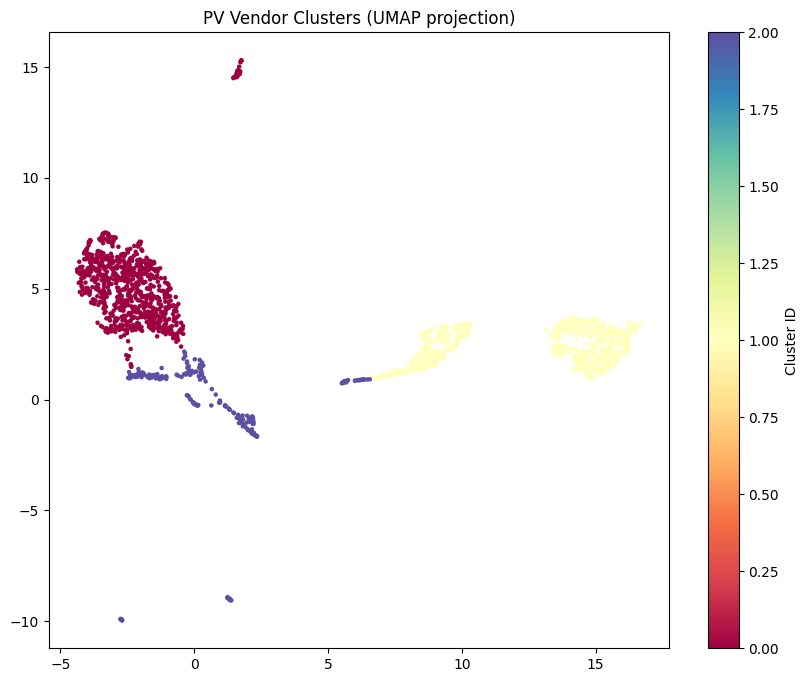

In [13]:

# ==========================================
# MAIN EXECUTION
# ==========================================
# if name == "main":
# 1. Setup Transforms (Resize & Normalize)
# We use ImageNet normalization stats because the model was trained on it
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# 2. Load Data
dataset = UnlabeledPVDatasett(INPUT_FOLDER, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

if len(dataset) == 0:
    print(f"No images found in {INPUT_FOLDER}. Please check the path.")
else:
    print(f"Found {len(dataset)} images.")
    
    # 3. Extract Features
    model = get_feature_extractor()
    features, filenames = extract_features(dataloader, model)
    
    # find_optimal_clusters(features)
    
    # 4. Cluster
    cluster_and_sort(features, filenames)
 

In [17]:

def get_model_and_transform():
    print("Loading ResNet model...")
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model = nn.Sequential(*list(model.children())[:-1])
    model.to(DEVICE)
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return model, transform


def extract_features_from_scratch(clusters):
    """Runs the slow model to get features."""
    model, transform = get_model_and_transform()
    data_cache = {} # Dictionary to store {cluster_name: {'paths': [], 'embeddings': []}}

    print(f"Extracting features for {len(clusters)} clusters...")
    
    for cluster in clusters:
        cluster_path = os.path.join(ROOT_DIR, cluster)
        image_files = sorted([os.path.join(cluster_path, f) for f in os.listdir(cluster_path) 
                       if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
        
        if len(image_files) < 3: continue

        embeddings = []
        valid_paths = []
        
        # Process batch-by-batch or one-by-one
        for p in tqdm(image_files, desc=f"Processing {cluster}"):
            try:
                img = Image.open(p).convert('RGB')
                img_t = transform(img).unsqueeze(0).to(DEVICE)
                with torch.no_grad():
                    emb = model(img_t).flatten().cpu().numpy()
                embeddings.append(emb)
                valid_paths.append(p)
            except Exception as e:
                print(f"Error reading {p}: {e}")

        if embeddings:
            data_cache[cluster] = {
                'paths': valid_paths,
                'embeddings': np.array(embeddings)
            }
            
    # Save to disk
    print(f"Saving features to {CACHE_FILE}...")
    torch.save(data_cache, CACHE_FILE)
    return data_cache


def visualize_outliers(cluster_name, outlier_paths, distances):
    if not outlier_paths: return
    
    # Setup plot
    num_imgs = len(outlier_paths)
    fig, axes = plt.subplots(1, num_imgs, figsize=(3 * num_imgs, 4))
    if num_imgs == 1: axes = [axes]
    
    fig.suptitle(f"Top Outliers in: {cluster_name}", fontsize=16)
    
    for i, (path, dist) in enumerate(zip(outlier_paths, distances)):
        try:
            img = Image.open(path)
            axes[i].imshow(img)
            axes[i].set_title(f"Dist: {dist:.4f}\n{os.path.basename(path)}")
            axes[i].axis('off')
        except:
            pass
    
    plt.tight_layout()
    plt.show()

def sort_final_cluster_and_visualize():
    clusters = sorted([d for d in os.listdir(ROOT_DIR) if os.path.isdir(os.path.join(ROOT_DIR, d))])
    
    # --- 1. SMART LOADING ---
    if os.path.exists(CACHE_FILE):
        print(f"✅ Found cached features in {CACHE_FILE}. Loading instantly...")
        data_cache = torch.load(CACHE_FILE, weights_only=False)
    else:
        print("❌ No cache found. Running feature extraction (This happens only once)...")
        data_cache = extract_features_from_scratch(clusters)

    # --- 2. FAST ANALYSIS ---
    print("\n--- Analysing Outliers ---")
    for cluster_name, data in data_cache.items():
        embeddings = data['embeddings']
        paths = data['paths']
        
        if len(embeddings) < 3: continue

        # Calculate Centroid
        centroid = np.mean(embeddings, axis=0).reshape(1, -1)
        
        # Calculate Distances
        dists = cosine_distances(embeddings, centroid).flatten()
        
        # Find Outliers
        outlier_indices = np.argsort(dists)[-TOP_N_OUTLIERS:][::-1]
        
        outlier_paths = [paths[i] for i in outlier_indices]
        outlier_dists = [dists[i] for i in outlier_indices]

        visualize_outliers(cluster_name, outlier_paths, outlier_dists)
        
        outlier_indices = np.argsort(dists)[:TOP_N_OUTLIERS][::-1]
        
        outlier_paths = [paths[i] for i in outlier_indices]
        outlier_dists = [dists[i] for i in outlier_indices]
        
        visualize_outliers(cluster_name, outlier_paths, outlier_dists)



❌ No cache found. Running feature extraction (This happens only once)...
Loading ResNet model...
Extracting features for 4 clusters...


Processing vendor_2: 100%|██████████| 3194/3194 [00:52<00:00, 61.31it/s]


Saving features to cell_separation_from_mixed_orig/resnet_features_cache_after_clean_grp4.pt...

--- Analysing Outliers ---


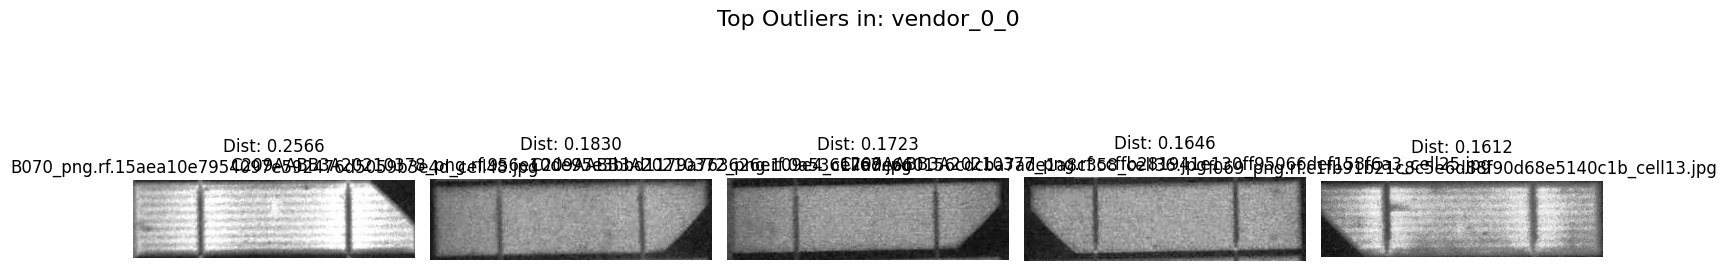

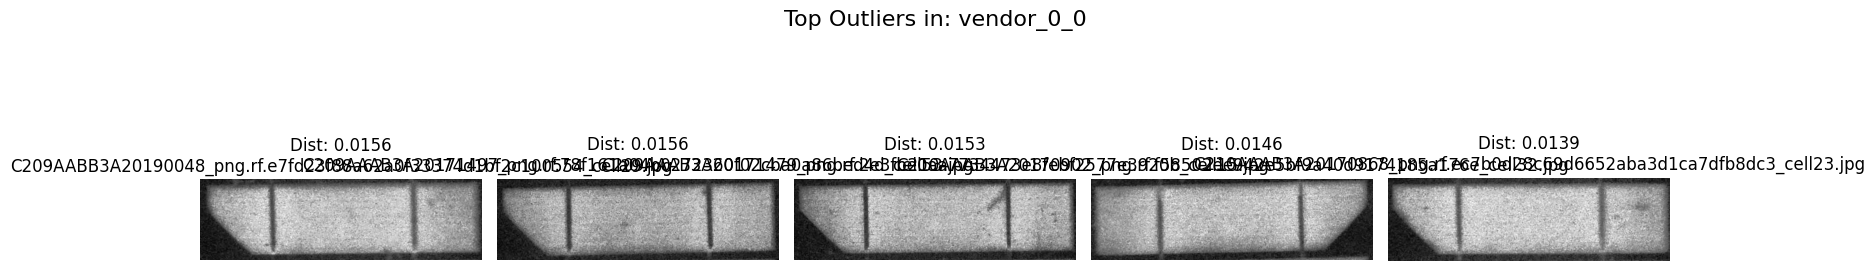

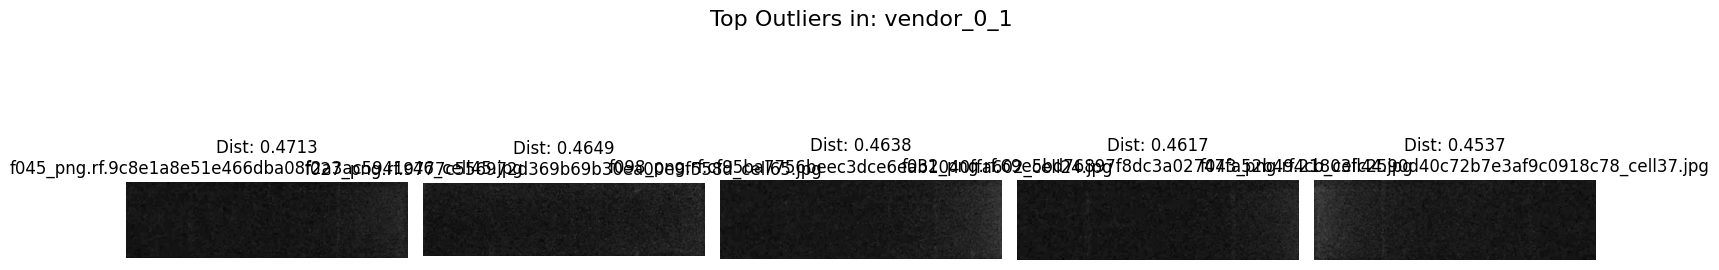

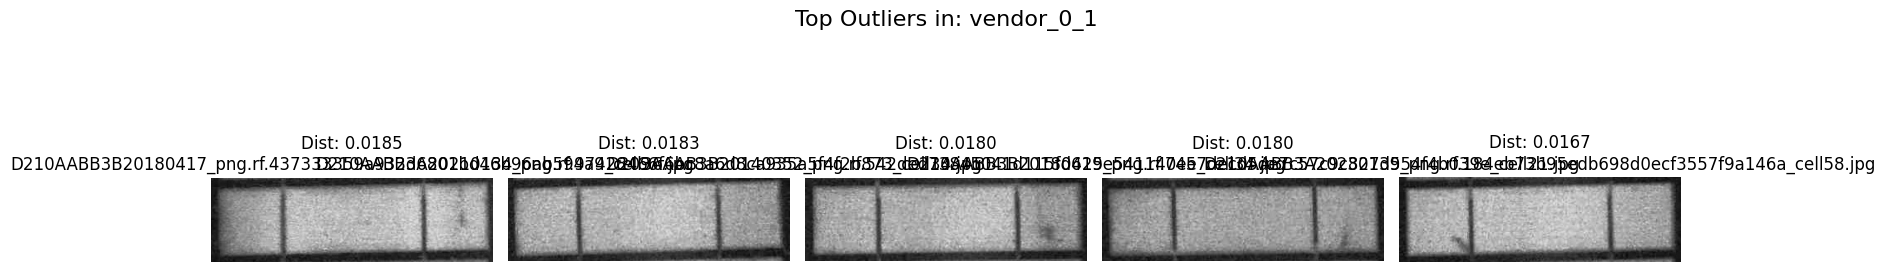

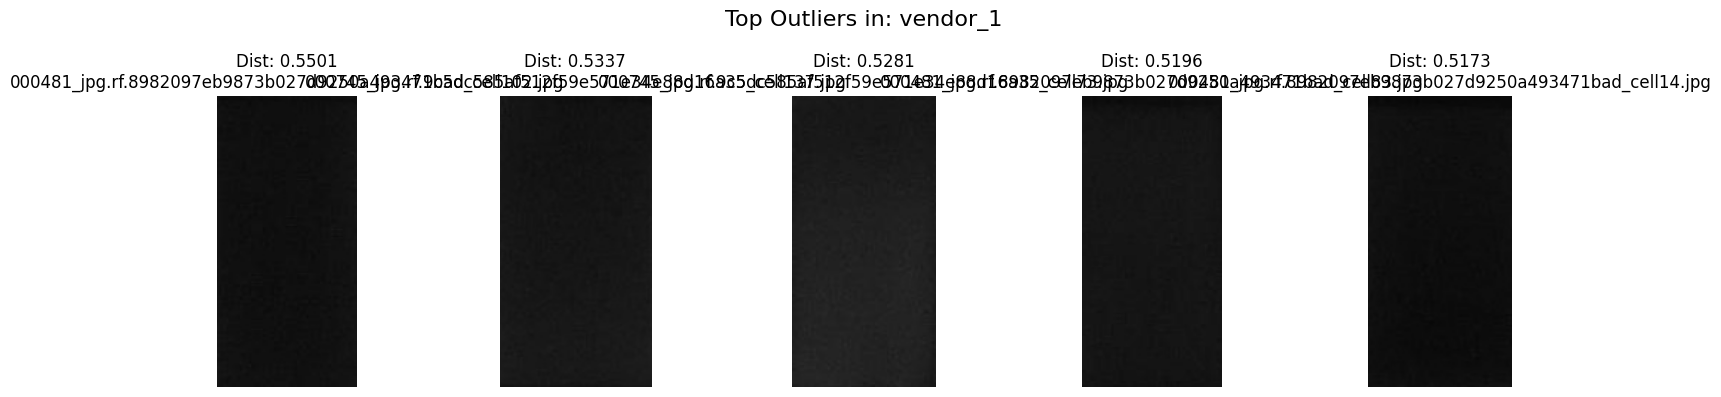

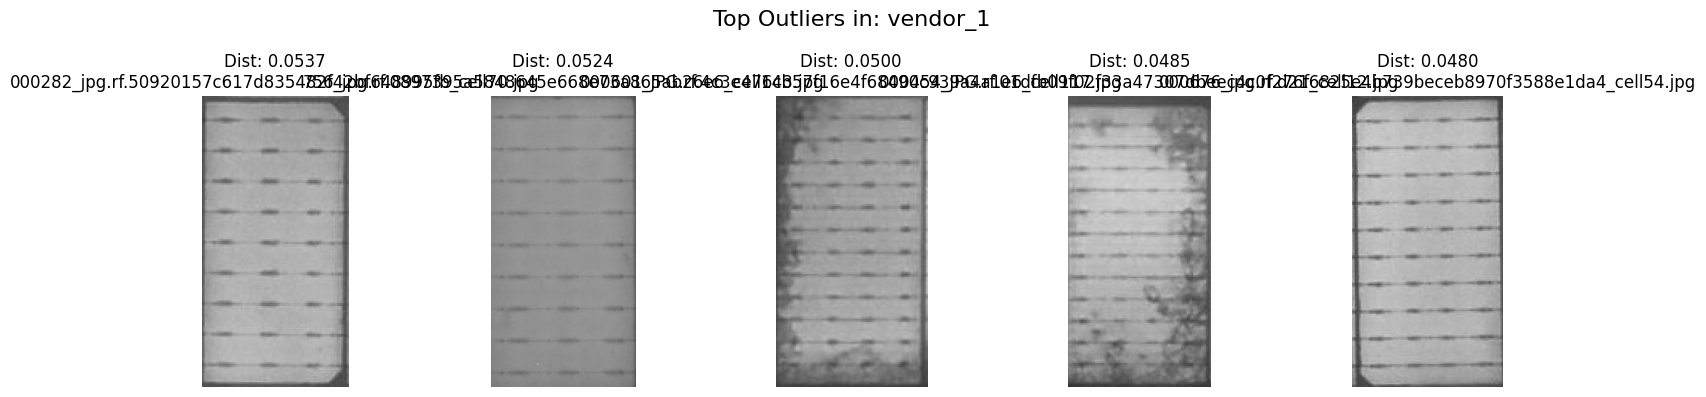

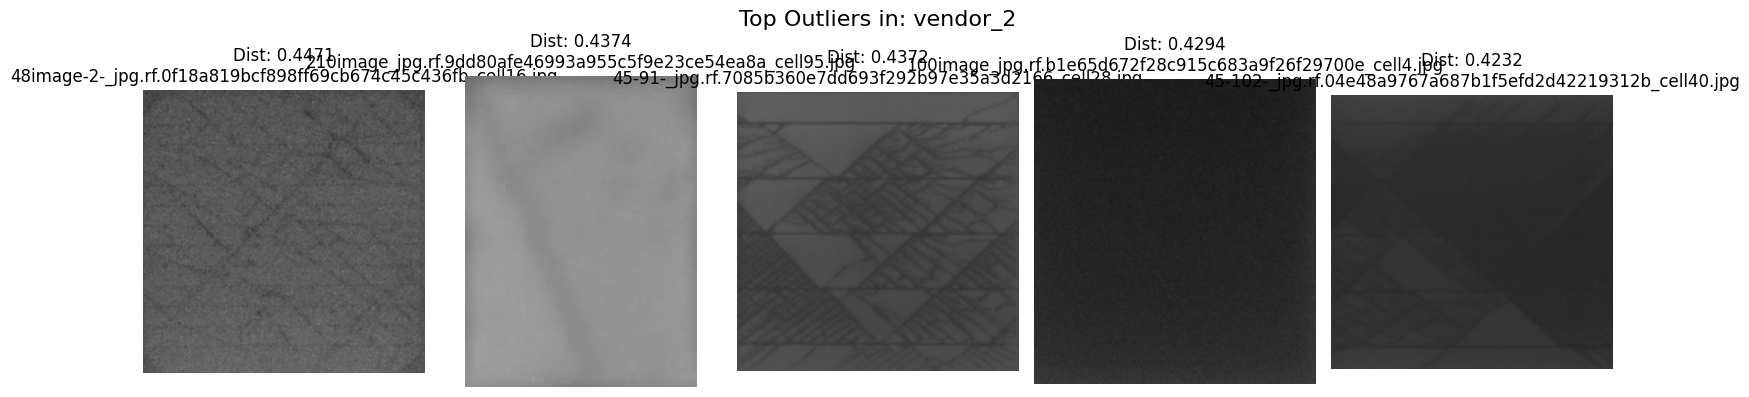

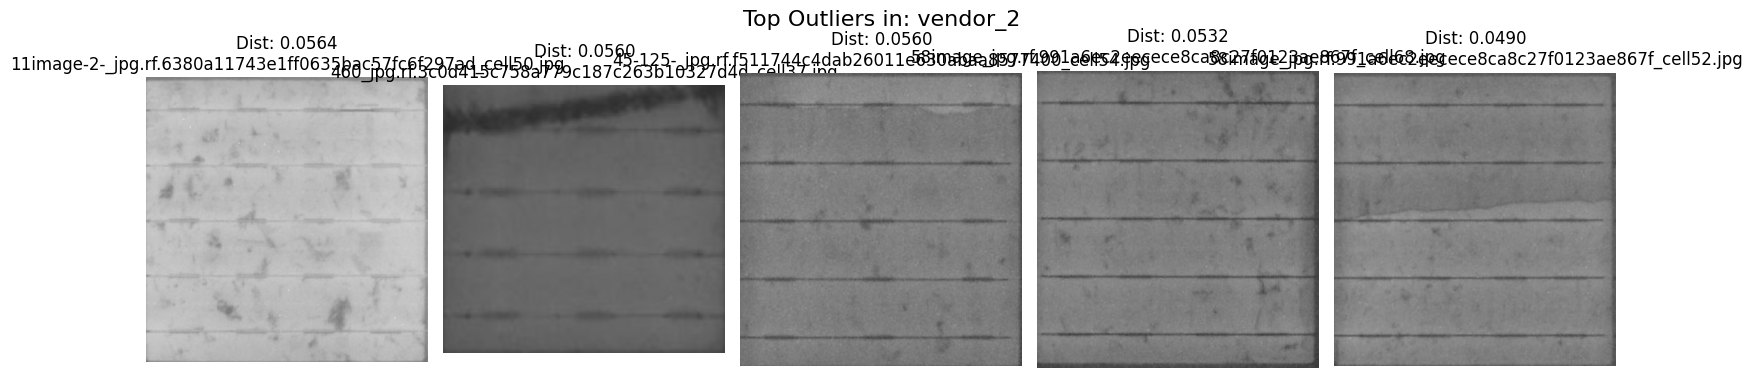

In [18]:
sort_final_cluster_and_visualize()

In [16]:


def find_label_file(base_name, search_dirs):
    """Searches for base_name.txt in a list of directories."""
    target_file = base_name + ".txt"
    for folder in search_dirs:
        if not os.path.exists(folder): continue
        candidate = os.path.join(folder, target_file)
        if os.path.exists(candidate):
            return candidate
    return None 


def copy_files(image_list, src_folder, dst_img_dir, dst_lbl_dir, label_dirs):
    """Helper to copy a list of images and their labels."""
    count = 0
    missing = 0
    
    for img_file in image_list:
        # Copy Image
        src_img = os.path.join(src_folder, img_file)
        dst_img = os.path.join(dst_img_dir, img_file)
        shutil.copy2(src_img, dst_img)
        
        # Find & Copy Label
        base_name = os.path.splitext(img_file)[0]
        label_path = find_label_file(base_name, label_dirs)
        
        if label_path:
            dst_lbl = os.path.join(dst_lbl_dir, base_name + ".txt")
            shutil.copy2(label_path, dst_lbl)
            count += 1
        else:
            missing += 1
            
    return count, missing


def organize_final_yolo_data():
    # Setup Output
    if os.path.exists(FINAL_OUTPUT_ROOT):
        shutil.rmtree(FINAL_OUTPUT_ROOT)
    os.makedirs(FINAL_OUTPUT_ROOT)

    # Get Vendors
    vendors = [d for d in os.listdir(CLEANED_IMAGES_ROOT) 
               if os.path.isdir(os.path.join(CLEANED_IMAGES_ROOT, d)) 
               and d not in IGNORE_FOLDERS] 

    print(f"Processing {len(vendors)} vendors...")

    for vendor in vendors:
        print(f"\n--- Splitting Dataset for: {vendor} ---")
        
        src_img_dir = os.path.join(CLEANED_IMAGES_ROOT, vendor)
        
        # Define Destinations
        train_img_dir = os.path.join(FINAL_OUTPUT_ROOT, vendor, 'train', 'images')
        train_lbl_dir = os.path.join(FINAL_OUTPUT_ROOT, vendor, 'train', 'labels')
        val_img_dir = os.path.join(FINAL_OUTPUT_ROOT, vendor, 'valid', 'images')
        val_lbl_dir = os.path.join(FINAL_OUTPUT_ROOT, vendor, 'valid', 'labels')
        
        for d in [train_img_dir, train_lbl_dir, val_img_dir, val_lbl_dir]:
            os.makedirs(d, exist_ok=True)
        
        # Get all images and Shuffle
        all_images = [f for f in os.listdir(src_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        random.shuffle(all_images)
        
        # Calculate Split Index
        split_idx = int(len(all_images) * (1 - VAL_PERCENT))
        train_files = all_images[:split_idx]
        val_files = all_images[split_idx:]
        
        print(f"  -> Found {len(all_images)} images.")
        print(f"  -> Training: {len(train_files)} | Validation: {len(val_files)}")
        
        # Process Splits
        t_count, t_miss = copy_files(train_files, src_img_dir, train_img_dir, train_lbl_dir, SOURCE_LABEL_DIRS)
        v_count, v_miss = copy_files(val_files, src_img_dir, val_img_dir, val_lbl_dir, SOURCE_LABEL_DIRS)
        
        if t_miss + v_miss > 0:
            print(f"  ⚠️ Warning: Missing labels for {t_miss + v_miss} images.")

    print("\n" + "="*40)
    print(f"✅ DATASET CREATION COMPLETE")
    print(f"📂 Location: {FINAL_OUTPUT_ROOT}")
    print("="*40)
    print("Structure:")
    print("final_yolo_datasets/")
    print("  ├── vendor_cluster_0/")
    print("  │   ├── train/")
    print("  │   │   ├── images/ (80%)")
    print("  │   │   └── labels/")
    print("  │   └── valid/")
    print("  │       ├── images/ (20%)")
    print("  │       └── labels/")



In [23]:

# ================= CONFIGURATION =================
# 1. Where are the NEW images you want to classify?
NEW_IMAGES_DIR = r'C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_cropped_ready_integ\removed_excess_backgrounds\train\images'
NEW_IMAGES_DIR = r'C:\Users\Rowan\Documents\Rowan\Yolo_test\pv_cropped_ready_integ\removed_excess_backgrounds\valid\images'

# 2. Where should we put them after classifying?
OUTPUT_DIR = r'cell_separation_from_mixed_orig/predicted_clusters_allpv_integ_data\train\images'
OUTPUT_DIR = r'cell_separation_from_mixed_orig/predicted_clusters_allpv_integ_data\valid\images'

# 3. The cache file from the previous step (contains the "Brain" of your clusters)
CACHE_FILE = r'cell_separation_from_mixed_orig/resnet_features_cache_after_clean_grp4.pt'  # Where to save the "fingerprints"

# =================================================


def get_cluster_centroids(cache_file):
    """Calculates the center point of every cluster in your cache."""
    if not os.path.exists(cache_file):
        raise FileNotFoundError(f"❌ Cache file '{cache_file}' not found! Run the previous script first.")
        
    print(f"Loading cluster data from {cache_file}...")
    data_cache = torch.load(cache_file)
    
    centroids = {}
    for cluster_name, data in data_cache.items():
        embeddings = data['embeddings']
        # The centroid is simply the average of all vectors in that cluster
        centroid = np.mean(embeddings, axis=0).reshape(1, -1)
        centroids[cluster_name] = centroid
        
    print(f"✅ Calculated centroids for {len(centroids)} clusters.")
    return centroids

def inference_to_classify():
    # 1. Setup
    if not os.path.exists(NEW_IMAGES_DIR):
        print(f"❌ Input folder '{NEW_IMAGES_DIR}' does not exist.")
        return

    # Prepare output folders
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR) # WARNING: Clears previous run
    os.makedirs(OUTPUT_DIR)
    
    # 2. Load "Brains"
    centroids = get_cluster_centroids(CACHE_FILE)
    cluster_names = list(centroids.keys())
    centroid_matrix = np.vstack(list(centroids.values())) # Stack them for fast math
    
    model, transform = get_model_and_transform()
    
    # 3. Process New Images
    new_images = [f for f in os.listdir(NEW_IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    print(f"Classifying {len(new_images)} new images...")
    
    for img_name in tqdm(new_images):
        img_path = os.path.join(NEW_IMAGES_DIR, img_name)
        
        try:
            # Extract Feature
            img = Image.open(img_path).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                emb = model(img_t).flatten().cpu().numpy().reshape(1, -1)
            
            # Compare to Centroids (Vectorized Math)
            # Calculate distance to ALL clusters at once
            dists = cosine_distances(emb, centroid_matrix).flatten()
            
            # Find the winner (Smallest distance)
            best_idx = np.argmin(dists)
            best_cluster = cluster_names[best_idx]
            confidence_dist = dists[best_idx]
            
            # 4. Action: Copy to folder
            target_folder = os.path.join(OUTPUT_DIR, best_cluster)
            os.makedirs(target_folder, exist_ok=True)
            
            # We add the distance to the filename for easy debugging
            # e.g. "image123_dist0.05.jpg"
            new_filename = f"{os.path.splitext(img_name)[0]}_d{confidence_dist:.3f}{os.path.splitext(img_name)[1]}"
            shutil.copy2(img_path, os.path.join(target_folder, new_filename))
            
        except Exception as e:
            print(f"Error processing {img_name}: {e}")


In [24]:
inference_to_classify()

Loading cluster data from cell_separation_from_mixed_orig/resnet_features_cache_after_clean_grp4.pt...


C:\Users\Rowan\AppData\Local\Temp\ipykernel_10468\3617448519.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_cache = torch.load(cache_file)


✅ Calculated centroids for 4 clusters.
Loading ResNet model...
Classifying 50768 new images...


100%|██████████| 50768/50768 [10:33<00:00, 80.19it/s] 


In [ ]:

import os
import shutil
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics.pairwise import cosine_distances
import numpy as np
from tqdm import tqdm

# ================= CONFIGURATION =================
# 1. Where are the unsorted images (mixed pool)?
UNSORTED_IMAGES_DIR = 'pv_cropped_ready_integ/train/images'

# 2. Where is your EXISTING Train/Val data? (To check for duplicates)
EXISTING_DATASET_ROOT = 'final_yolo_datasets'

# 3. Where are the labels located?
SOURCE_LABEL_DIRS = [
    'pv_cropped_ready_integ/train/labels', 
    'pv_cropped_ready_integ/valid/labels', 
]


def get_used_filenames(root_dir):
    """Scans the existing dataset to find all image names we used."""
    print(f"Scanning {root_dir} for existing images...")
    used = set()
    for root, dirs, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                used.add(f) # Store filename
    print(f"✅ Found {len(used)} images already in Train/Val. These will be skipped.")
    return used

def find_label_file(base_name, search_dirs):
    target_file = base_name + ".txt"
    for folder in search_dirs:
        if not os.path.exists(folder): continue
        candidate = os.path.join(folder, target_file)
        if os.path.exists(candidate):
            return candidate
    return None


def main():
    # 1. Load Resources
    if not os.path.exists(CACHE_FILE):
        print("❌ Error: features_cache.pt not found.")
        return

    # Load Centroids
    data_cache = torch.load(CACHE_FILE, weights_only=False)
    centroids = {}
    for cluster, data in data_cache.items():
        centroids[cluster] = np.mean(data['embeddings'], axis=0).reshape(1, -1)
    
    centroid_matrix = np.vstack(list(centroids.values()))
    cluster_names = list(centroids.keys())
    
    # Load Model
    model, transform = get_model_and_transform()
    
    # Load Blacklist (Used Images)
    used_filenames = get_used_filenames(EXISTING_DATASET_ROOT)

    # 2. Process New Images
    new_images = [f for f in os.listdir(UNSORTED_IMAGES_DIR) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    print(f"Processing {len(new_images)} candidate images...")
    
    added_count = 0
    skipped_count = 0
    missing_label_count = 0

    for img_name in tqdm(new_images):
        # --- CHECK 1: DUPLICATE? ---
        if img_name in used_filenames:
            skipped_count += 1
            continue
            
        img_path = os.path.join(UNSORTED_IMAGES_DIR, img_name)
        
        try:
            # --- CHECK 2: CLASSIFY ---
            img = Image.open(img_path).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                emb = model(img_t).flatten().cpu().numpy().reshape(1, -1)
            
            # Find nearest cluster
            dists = cosine_distances(emb, centroid_matrix).flatten()
            best_idx = np.argmin(dists)
            best_cluster = cluster_names[best_idx]
            
            # --- CHECK 3: MOVE TO TEST FOLDER ---
            # Define destination: final_yolo_datasets/vendor_X/test/images
            dest_img_dir = os.path.join(EXISTING_DATASET_ROOT, best_cluster, 'test', 'images')
            dest_lbl_dir = os.path.join(EXISTING_DATASET_ROOT, best_cluster, 'test', 'labels')
            os.makedirs(dest_img_dir, exist_ok=True)
            os.makedirs(dest_lbl_dir, exist_ok=True)
            
            # Copy Image
            shutil.copy2(img_path, os.path.join(dest_img_dir, img_name))
            
            # Find & Copy Label
            base_name = os.path.splitext(img_name)[0]
            label_path = find_label_file(base_name, SOURCE_LABEL_DIRS)
            
            if label_path:
                shutil.copy2(label_path, os.path.join(dest_lbl_dir, base_name + ".txt"))
            else:
                missing_label_count += 1
                # Optional: Create empty label file if needed
                # open(os.path.join(dest_lbl_dir, base_name + ".txt"), 'a').close()
            
            added_count += 1
            
        except Exception as e:
            print(f"Error processing {img_name}: {e}")

    print("\n" + "="*40)
    print("TEST SET CREATION REPORT")
    print(f"✅ Added to Test Set: {added_count}")
    print(f"⏭️ Skipped (Duplicate): {skipped_count}")
    print(f"⚠️ Missing Labels:      {missing_label_count}")
    print("="*40)
    print("Your dataset now looks like this:")
    print("final_yolo_datasets/")
    print("  ├── vendor_cluster_0/")
    print("  │   ├── train/ (Images you already had)")
    print("  │   ├── valid/ (Images you already had)")
    print("  │   └── test/  (NEW UNIQUE IMAGES)")



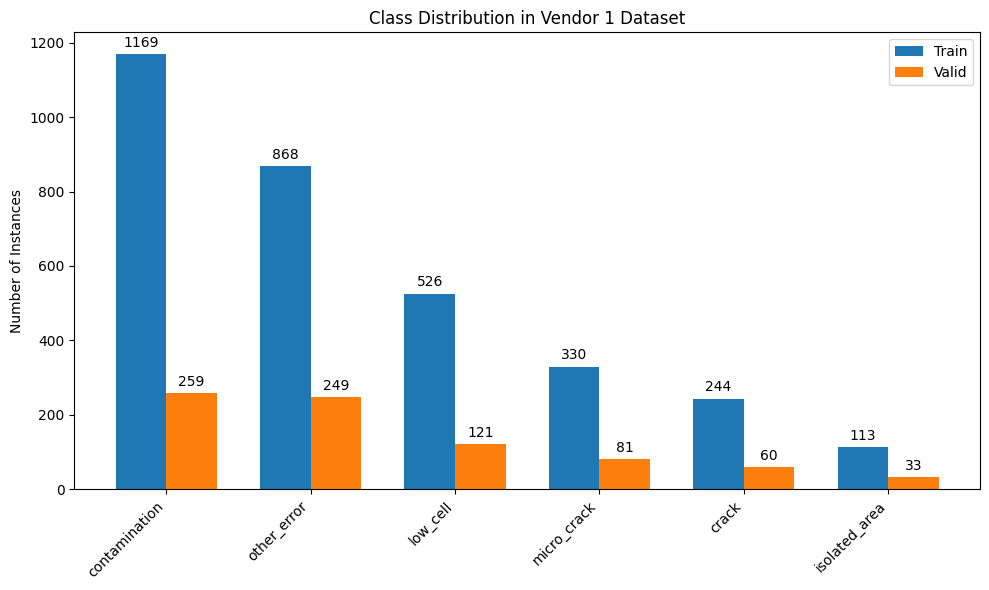

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your scan
classes = ['contamination', 'other_error', 'low_cell', 'micro_crack', 'crack', 'isolated_area']
train_counts = [1169, 868, 526, 330, 244, 113]
valid_counts = [259, 249, 121, 81, 60, 33]

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(classes))
width = 0.35

# Create bars
rects1 = ax.bar(x - width/2, train_counts, width, label='Train')
rects2 = ax.bar(x + width/2, valid_counts, width, label='Valid')

# Add labels and title
ax.set_ylabel('Number of Instances')
ax.set_title('Class Distribution in Vendor 1 Dataset')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()

# Attach count labels above bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()

In [ ]:
import yaml
import shutil
import os

# Path to your original data.yaml
idx = "2"
data_path = rf'C:\Users\Rowan\Documents\Rowan\Yolo_test\cell_separation_from_mixed_orig\final_yolo_datasets_without_other_err_cls\vendor_{idx}\data.yaml'

# Load data
with open(data_path, 'r') as f:
    data = yaml.safe_load(f)

# Define classes to drop (based on your scan having 0 counts)
classes_to_drop = {"0": ['contamination', 'examined'], "1": [], "2": ['other_error', 'examined']}

# Prepare the names dictionary
# Ensure 'names' is treated as a dictionary indexed by integers
# If it was a list ['cat', 'dog'], it becomes {0: 'cat', 1: 'dog'}
data['names'] = dict(enumerate(data['names']))

# --- STEP 1: Create Mapping and Update YAML ---

new_names = {}
id_mapping = {}  # To store: {old_id: new_id}
current_idx = 0

# Sort items by old index to ensure consistent re-indexing
for old_idx, name in sorted(data['names'].items()):
    if name not in classes_to_drop[idx]:
        # Keep this class
        new_names[str(current_idx)] = name
        # Record that old_idx now maps to current_idx
        id_mapping[int(old_idx)] = current_idx
        current_idx += 1
    else:
        # This class is dropped, so it gets no new entry in id_mapping
        pass

# Update the data dictionary
data['names'] = new_names
data['nc'] = len(new_names)

# Save the cleaned yaml (backup the original first)
shutil.copy(data_path, data_path + '.backup')
with open(data_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print(f"Updated data.yaml. New class count (nc): {data['nc']}")
print(f"New Classes: {data['names']}")
print(f"ID Mapping (Old -> New): {id_mapping}")


# --- STEP 2: Update the Label Files (.txt) ---

print("\nStarting label file update...")

# Get the directory where data.yaml is located to resolve relative paths
yaml_dir = os.path.dirname(data_path)

# Identify dataset splits (train, val, test)
splits = ['train', 'val', 'test']
for split in splits:
    if split in data:
        print(f"Processing {split} set...")
        
        # Construct absolute path to the images folder defined in YAML
        # Example: data['train'] might be 'images/train'
        img_rel_path = data[split]
        img_abs_path = os.path.join(yaml_dir, img_rel_path)
        
        # Assuming standard YOLO structure: 'images' folder has a parallel 'labels' folder
        # We replace 'images' with 'labels' in the path
        label_abs_path = img_abs_path.replace('images', 'labels')
        
        if not os.path.exists(label_abs_path):
            print(f"Warning: Could not find label directory at {label_abs_path}. Skipping.")
            continue

        # Iterate through all .txt files in the label directory
        for filename in os.listdir(label_abs_path):
            if filename.endswith(".txt"):
                file_path = os.path.join(label_abs_path, filename)
                
                new_lines = []
                with open(file_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if not parts:
                            continue
                            
                        try:
                            old_class_id = int(parts[0])
                        except ValueError:
                            continue # Skip malformed lines

                        # Check if this class ID exists in our mapping (i.e., was it dropped?)
                        if old_class_id in id_mapping:
                            # Update the ID to the new sequential index
                            new_class_id = id_mapping[old_class_id]
                            parts[0] = str(new_class_id)
                            new_lines.append(" ".join(parts))
                        # Else: The class was dropped, so we do not append the line (filtering it out)

                # Overwrite the file with the updated lines
                with open(file_path, 'w') as f:
                    f.write('\n'.join(new_lines))

print("Label file update complete.")

Updated data.yaml. New class count (nc): 6
New Classes: {'0': 'micro_crack', '1': 'crack', '2': 'low_cell', '3': 'low_string', '4': 'isolated_area', '5': 'contamination'}


In [1]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt") # or yolov8s.pt

model.train(
    data=r"C:\Users\Rowan\Documents\Rowan\Yolo_test\cell_separation_from_mixed_orig\final_yolo_datasets_without_other_err_cls\vendor_0\data.yaml",
    cfg=r"final_env_yolo\Lib\site-packages\ultralytics\cfg\default copy.yaml",
    # 1. RESOLUTION FIX
    imgsz=640,          # Increased to see thin cracks
    
    # 2. BATCH SIZE (adjust based on GPU VRAM)
    batch=16,            # Lower batch to fit higher res
    
    epochs=20,         # More epochs for higher res
    
    # 3. AUGMENTATION TUNING
    mosaic=1.0,         # Keep 0 if you have clean single-cell crops
    mixup=0.15,         # Adds robustness without cutting cells
    copy_paste=0.0,     # Turn off for now. Copy-paste on top of grid lines looks fake.
    
    # EL Specific Augs
    # hsv_v=0.4,          # Randomize brightness (Crucial for EL)
    # blur=0.1,           # Simulate focus variations
    # contrast=0.2,       # Simulate current variations
    
    # Geometric Augs
    scale=0.5,          # Zoom in/out (helps detect large vs small defects)
    # flipud=0.5,         # Vertical flip is fine
    fliplr=0.5,         # Horizontal flip is fine (cells are symmetric)
    translate=0.1,      # Small translation only
    degrees=5.0,       # Slight rotation
    
    # 4. OPTIMIZER TWEAKS
    # lr0=0.001,          # Slightly lower learning rate for stability at high res
    # box=10.0,           # Higher box gain to tighten mAP50-95
    
    cls=1.0,
    kobj=2.0,
    # fl_gamma=0.0,
    label_smoothing=0.0,

    workers=2,
    device=0,
    patience=20,
)

New https://pypi.org/project/ultralytics/8.4.6 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.245  Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=final_env_yolo\Lib\site-packages\ultralytics\cfg\default copy.yaml, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Rowan\Documents\Rowan\Yolo_test\cell_separation_from_mixed_orig\final_yolo_datasets_without_other_err_cls\vendor_0\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

c:\Users\Rowan\Documents\Rowan\Yolo_test\final_env_yolo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.1 ms, read: 101.480.9 MB/s, size: 33.3 KB)
val: Scanning C:\Users\Rowan\Documents\Rowan\Yolo_test\cell_separation_from_mixed_orig\final_yolo_datasets\vendor_0\valid\labels.cache... 1739 images, 150 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1889/1889 1.9Mit/s 0.0s
Plotting labels to C:\Users\Rowan\Documents\Rowan\Yolo_test\runs\detect\train121\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to C:\Users\Rowan\Documents\Rowan\Yolo

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [12]:
# Calculate Inverse Frequency Weights for your dataset
import numpy as np

# Your instance counts from the scan
classes = ['contamination', 'other_error', 'low_cell', 'micro_crack', 'crack', 'isolated_area']
counts = [1428, 1117, 647, 411, 304, 146]

# 1. Calculate Weights: weight = (1 / count) * median_of_counts
# This ensures rare classes get higher weights
median_count = np.median(counts)
weights = (1.0 / np.array(counts)) * median_count

# Normalize so the highest weight is 1.0 (optional, helps stability)
weights = weights / np.max(weights)

print("--- Recommended Class Weights (for Loss Function) ---")
for cls, w in zip(classes, weights):
    print(f"{cls}: {w:.4f}")

# Example Output Interpretation:
# 'isolated_area' might get a weight of ~2.5 (high importance)
# 'contamination' might get a weight of ~0.5 (lower importance)

--- Recommended Class Weights (for Loss Function) ---
contamination: 0.1022
other_error: 0.1307
low_cell: 0.2257
micro_crack: 0.3552
crack: 0.4803
isolated_area: 1.0000
